Data Visualization


In [1]:
import pandas as pd

df = pd.read_csv("/content/Nextera_dataset.csv")

print(df.shape)
df.head()

(20434, 18)


,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,in_balanced_dataset
0,Marketing Intern,"US, NY, New York",Marketing,NaN,"<h3>We're Food52, and we've created a groundbr...","<p>Food52, a fast-growing, James Beard Award-w...",<ul>\r\n<li>Experience with content management...,NaN,f,t,f,Other,Internship,NaN,NaN,Marketing,f,f
1,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"<h3>90 Seconds, the worlds Cloud Video Product...",<p>Organised - Focused - Vibrant - Awesome!<br...,<p><b>What we expect from you:</b></p>\r\n<p>Y...,<h3><b>What you will get from us</b></h3>\r\n<...,f,t,f,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,f,f
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,<h3></h3>\r\n<p>Valor Services provides Workfo...,"<p>Our client, located in Houston, is actively...",<ul>\r\n<li>Implement pre-commissioning and co...,NaN,f,t,f,NaN,NaN,NaN,NaN,NaN,f,f
3,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,<p>Our passion for improving quality of life t...,<p><b>THE COMPANY: ESRI – Environmental System...,<ul>\r\n<li>\r\n<b>EDUCATION: </b>Bachelor’s o...,<p>Our culture is anything but corporate—we ha...,f,t,f,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,f,f
4,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,<p>SpotSource Solutions LLC is a Global Human ...,<p><b>JOB TITLE:</b> Itemization Review Manage...,<p><b>QUALIFICATIONS:</b></p>\r\n<ul>\r\n<li>R...,<p>Full Benefits Offered</p>,f,t,t,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,f,f


In [2]:
print(df.columns.tolist())

['title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent', 'in_balanced_dataset']


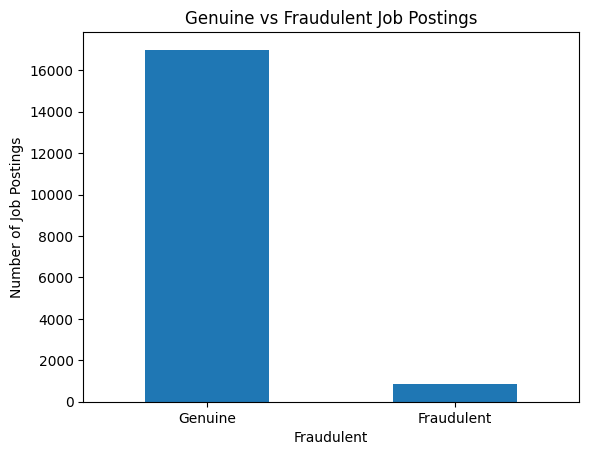

In [3]:
import matplotlib.pyplot as plt

df["fraudulent"].value_counts().plot(kind="bar")

plt.title("Genuine vs Fraudulent Job Postings")
plt.xlabel("Fraudulent")
plt.ylabel("Number of Job Postings")
plt.xticks([0, 1], ["Genuine", "Fraudulent"], rotation=0)
plt.show()

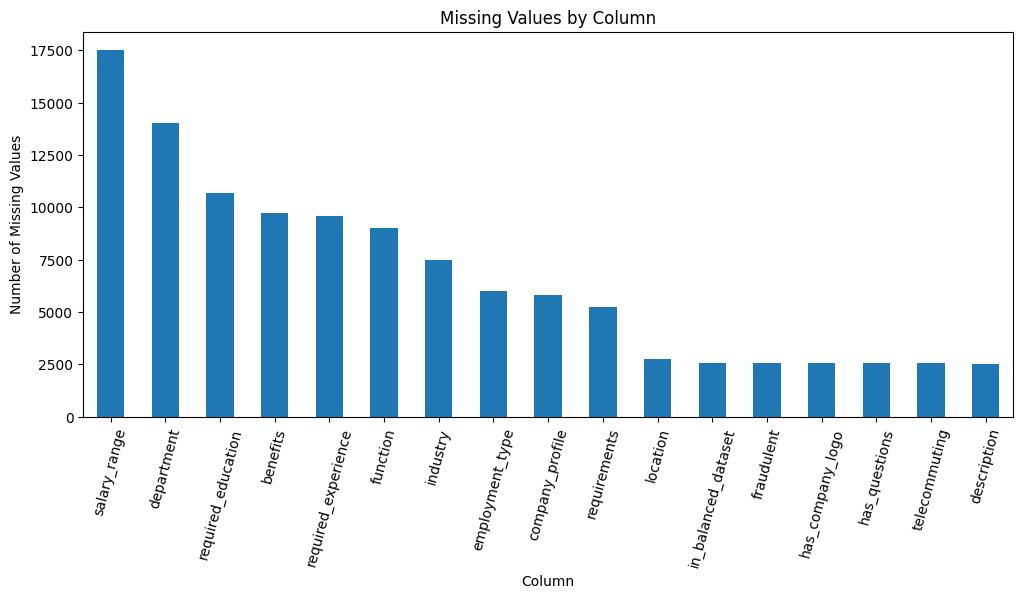

In [4]:
missing = df.isnull().sum().sort_values(ascending=False)

missing = missing[missing > 0]

missing.plot(kind="bar", figsize=(12, 5))

plt.title("Missing Values by Column")
plt.xlabel("Column")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=75)
plt.show()

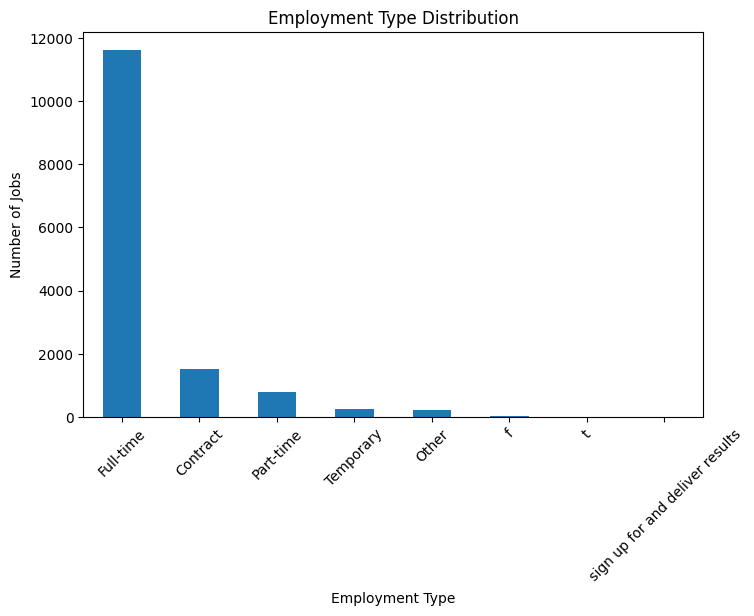

In [5]:
df["employment_type"].value_counts().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Employment Type Distribution")
plt.xlabel("Employment Type")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)
plt.show()

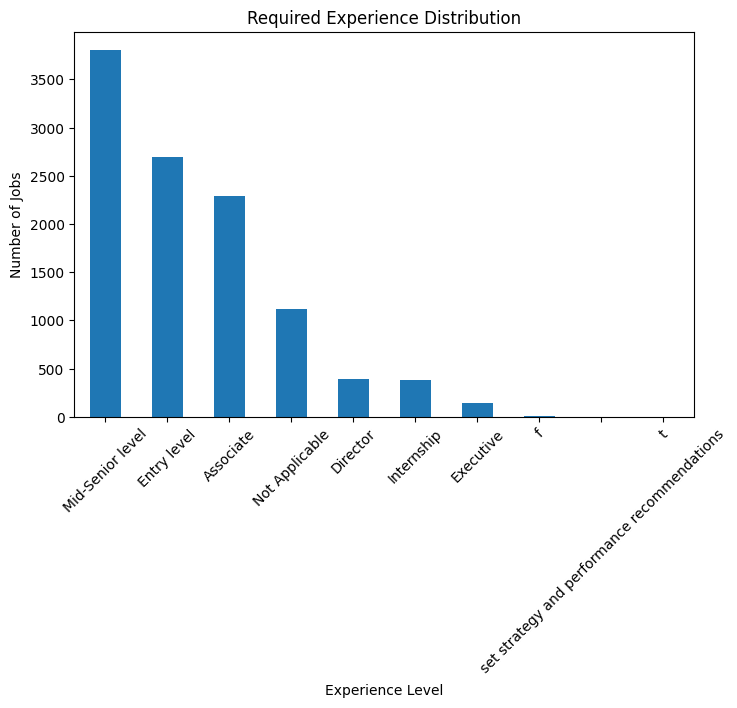

In [6]:
df["required_experience"].value_counts().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Required Experience Distribution")
plt.xlabel("Experience Level")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)
plt.show()

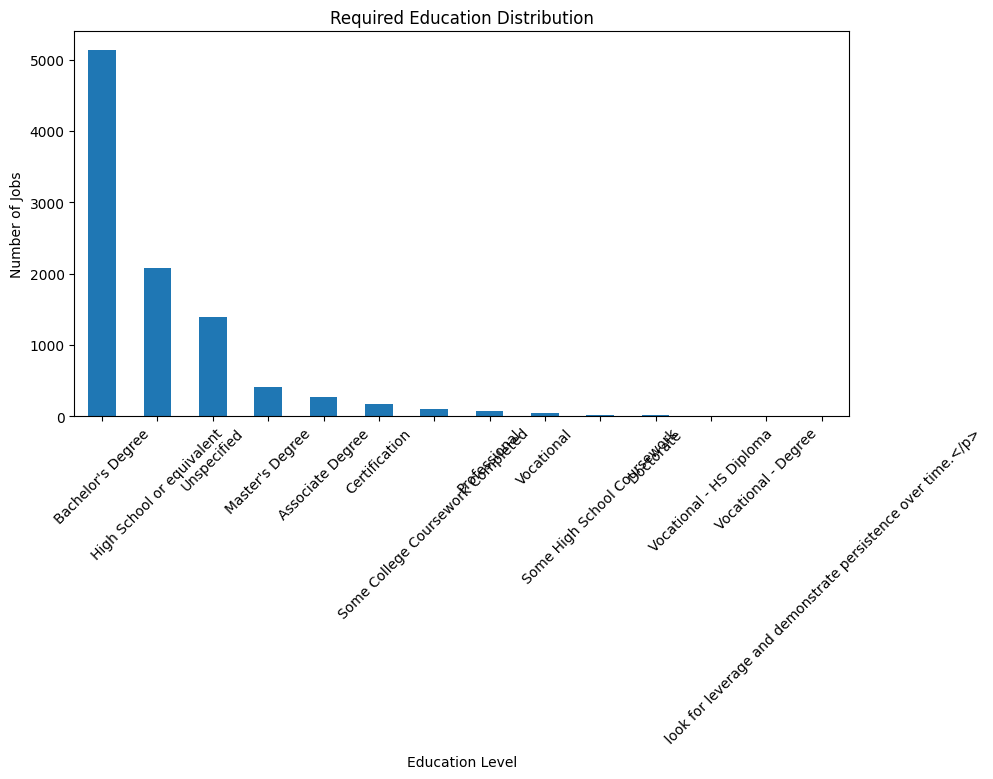

In [7]:
df["required_education"].value_counts().plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Required Education Distribution")
plt.xlabel("Education Level")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)
plt.show()

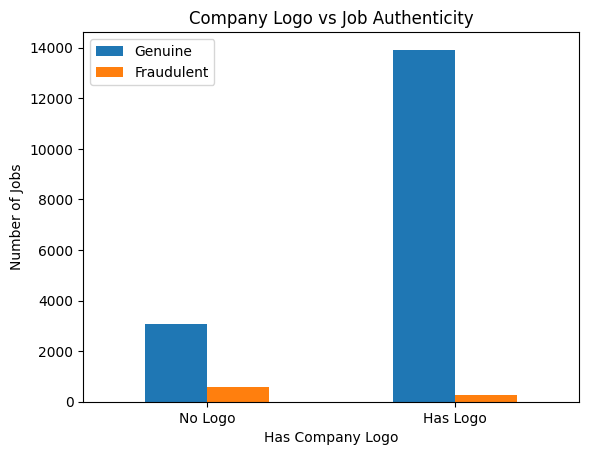

In [8]:
pd.crosstab(
    df["has_company_logo"],
    df["fraudulent"]
).plot(kind="bar")

plt.title("Company Logo vs Job Authenticity")
plt.xlabel("Has Company Logo")
plt.ylabel("Number of Jobs")
plt.xticks([0, 1], ["No Logo", "Has Logo"], rotation=0)
plt.legend(["Genuine", "Fraudulent"])
plt.show()

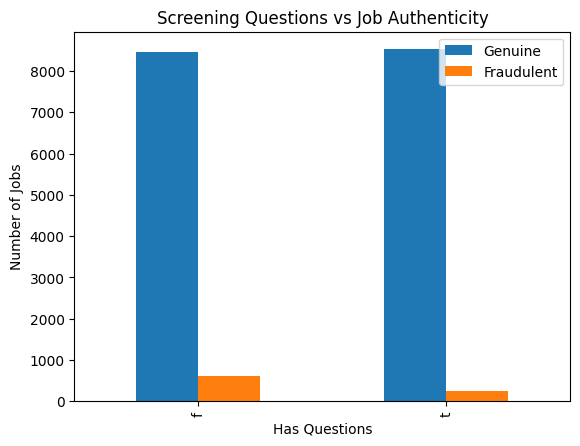

In [9]:
pd.crosstab(
    df["has_questions"],
    df["fraudulent"]
).plot(kind="bar")

plt.title("Screening Questions vs Job Authenticity")
plt.xlabel("Has Questions")
plt.ylabel("Number of Jobs")
plt.legend(["Genuine", "Fraudulent"])
plt.show()

Data Preprocessing

CHECKING MISSING VALUES

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20434 entries, 0 to 20433
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   title                20434 non-null  object
 1   location             17664 non-null  object
 2   department           6412 non-null   object
 3   salary_range         2924 non-null   object
 4   company_profile      14611 non-null  object
 5   description          17911 non-null  object
 6   requirements         15196 non-null  object
 7   benefits             10684 non-null  object
 8   telecommuting        17878 non-null  object
 9   has_company_logo     17877 non-null  object
 10  has_questions        17878 non-null  object
 11  employment_type      14414 non-null  object
 12  required_experience  10829 non-null  object
 13  required_education   9766 non-null   object
 14  industry             12964 non-null  object
 15  function             11410 non-null  object
 16  frau

In [11]:
missing = df.isnull().sum()

print(missing[missing > 0])

location                2770
department             14022
salary_range           17510
company_profile         5823
description             2523
requirements            5238
benefits                9750
telecommuting           2556
has_company_logo        2557
has_questions           2556
employment_type         6020
required_experience     9605
required_education     10668
industry                7470
function                9024
fraudulent              2574
in_balanced_dataset     2574
dtype: int64


In [12]:
text_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

for col in text_columns:
    df[col] = df[col].fillna("")

In [13]:
categorical_columns = [
    "department",
    "employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function",
    "location"
]

for col in categorical_columns:
    df[col] = df[col].fillna("Unknown")

In [14]:
df["salary_range"] = df["salary_range"].fillna("Unknown")

CHECKING DUPLICATES

In [15]:
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 2281


In [16]:
df = df.drop_duplicates()

In [17]:
print("Duplicates after removal:", df.duplicated().sum())

Duplicates after removal: 0


In [18]:
for col in text_columns:
    empty_count = (df[col].str.strip() == "").sum()
    print(col, empty_count)

title 0
company_profile 3758
description 479
requirements 3156
benefits 7613


In [19]:
import re

def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [20]:
for col in text_columns:
    df[col] = df[col].apply(clean_text)

In [21]:
df["fraudulent"]

,fraudulent
0,f
1,f
2,f
3,f
4,f
...,...
20429,f
20430,f
20431,f
20432,f


In [22]:
print(df["fraudulent"].value_counts())

fraudulent
f    16767
t      858
Name: count, dtype: int64


In [23]:
print(df["fraudulent"].isnull().sum())


528


In [24]:
binary_columns = [
    "telecommuting",
    "has_company_logo",
    "has_questions",
    "fraudulent"
]

for col in binary_columns:
    print(col, df[col].unique())

telecommuting ['f' 't' nan 'Telecommunications'
 ' and entrepreneurial development in an open environment that allows for collisions and collaboration to thrive.</p>'
 'Consumer Services' "Bachelor's Degree" 'Consumer Goods'
 ' driving data integration and working closely with IT on enterprise resource planning systems to improve internal marketing programs and campaigns as well as increase the database value for partners and advertisers.</p>'
 ' CRM strategies and response' ' campaign measurement'
 'Some College Coursework Completed']
has_company_logo ['t' 'f' nan 'Sales' 'Customer Service' 'Engineering' 'Telecommunications'
 'Computer Software'
 ' behavioral and psychographic models and those predicting future performance. This individual must have a track record of successfully hiring and managing smart people'
 ' and business intelligence</p>' 'Data Analyst' 'Retail']
has_questions ['f' 't' nan 'Information Technology' 'Marketing' 'Sales' 'Engineering'
 ' <b>have a style of being a

In [25]:
print(df["in_balanced_dataset"].value_counts(dropna=False))

in_balanced_dataset
f      16733
t        892
NaN      528
Name: count, dtype: int64


In [26]:
print(df.shape)
print(df.isnull().sum())
df.head()

(18153, 18)
title                    0
location                 0
department               0
salary_range             0
company_profile          0
description              0
requirements             0
benefits                 0
telecommuting          512
has_company_logo       511
has_questions          510
employment_type          0
required_experience      0
required_education       0
industry                 0
function                 0
fraudulent             528
in_balanced_dataset    528
dtype: int64


,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,in_balanced_dataset
0,marketing intern,"US, NY, New York",Marketing,Unknown,"we're food52, and we've created a groundbreaki...","food52, a fast-growing, james beard award-winn...",experience with content management systems a m...,,f,t,f,Other,Internship,Unknown,Unknown,Marketing,f,f
1,customer service - cloud video production,"NZ, , Auckland",Success,Unknown,"90 seconds, the worlds cloud video production ...",organised - focused - vibrant - awesome!do you...,what we expect from you: your key responsibili...,what you will get from us through being part o...,f,t,f,Full-time,Not Applicable,Unknown,Marketing and Advertising,Customer Service,f,f
2,commissioning machinery assistant (cma),"US, IA, Wever",Unknown,Unknown,valor services provides workforce solutions th...,"our client, located in houston, is actively se...",implement pre-commissioning and commissioning ...,,f,t,f,Unknown,Unknown,Unknown,Unknown,Unknown,f,f
3,account executive - washington dc,"US, DC, Washington",Sales,Unknown,our passion for improving quality of life thro...,the company: esri – environmental systems rese...,"education: bachelor’s or master’s in gis, busi...",our culture is anything but corporate—we have ...,f,t,f,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,f,f
4,bill review manager,"US, FL, Fort Worth",Unknown,Unknown,spotsource solutions llc is a global human cap...,job title: itemization review manager location...,qualifications: rn license in the state of tex...,full benefits offered,f,t,t,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,f,f


In [27]:
df.to_csv("cleaned_job_dataset.csv", index=False)

FEATURE ENGINEERING

In [28]:
df["title_length"] = df["title"].str.len()
df["description_length"] = df["description"].str.len()
df["requirements_length"] = df["requirements"].str.len()
df["benefits_length"] = df["benefits"].str.len()

In [29]:
df["total_text_length"] = (
    df["title_length"] +
    df["description_length"] +
    df["requirements_length"] +
    df["benefits_length"]
)

ENCODIN

In [30]:
categorical_columns = [
    "employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function"
]

In [31]:
df_encoded = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

SCALING

In [32]:
numerical_columns = [
    "title_length",
    "description_length",
    "requirements_length",
    "benefits_length",
    "total_text_length"
]

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_encoded[numerical_columns] = scaler.fit_transform(
    df_encoded[numerical_columns]
)

In [34]:
drop_columns = [
    "fraudulent",
    "in_balanced_dataset"
]

In [35]:
X = df_encoded.drop(columns=["fraudulent"])
y = df_encoded["fraudulent"]

In [37]:
nan_counts = X.isnull().sum()

print(nan_counts[nan_counts > 0])

telecommuting          512
has_company_logo       511
has_questions          510
in_balanced_dataset    528
dtype: int64


In [38]:
print("Total NaN values:", X.isnull().sum().sum())

Total NaN values: 2061


In [39]:
print("NaN in X:", X.isnull().sum().sum())
print("NaN in y:", y.isnull().sum())

NaN in X: 2061
NaN in y: 528


In [40]:
df_encoded = df_encoded.dropna(subset=["fraudulent"])

In [41]:
X = df_encoded.drop(columns=["fraudulent"])
y = df_encoded["fraudulent"]

In [42]:
print("NaN in X:", X.isnull().sum().sum())
print("NaN in y:", y.isnull().sum())

NaN in X: 0
NaN in y: 0


In [43]:
binary_columns = [
    "telecommuting",
    "has_company_logo",
    "has_questions",
    "in_balanced_dataset"
]

for col in binary_columns:
    X[col] = X[col].fillna(0)

In [44]:
print("NaN in X:", X.isnull().sum().sum())
print("NaN in y:", y.isnull().sum())

NaN in X: 0
NaN in y: 0


TRAIN/TEST

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

LOGISTIC REGRESSION

In [47]:
print(X_train.dtypes)

title                         object
location                      object
department                    object
salary_range                  object
company_profile               object
                               ...  
function_Strategy/Planning      bool
function_Supply Chain           bool
function_Training               bool
function_Unknown                bool
function_Writing/Editing        bool
Length: 217, dtype: object


In [48]:
print(X_train.select_dtypes(include='object').columns.tolist())

['title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'in_balanced_dataset']


In [49]:
text_columns = [
    'title',
    'company_profile',
    'description',
    'requirements',
    'benefits',
    'location'
]

X = X.drop(columns=text_columns, errors='ignore')

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [52]:
print(X_train.select_dtypes(include="object").columns.tolist())

['department', 'salary_range', 'telecommuting', 'has_company_logo', 'has_questions', 'in_balanced_dataset']


In [53]:

X = pd.get_dummies(X, drop_first=True)

In [54]:
X = X.astype(int)

In [55]:
print("NaN values:", X.isnull().sum().sum())

NaN values: 0


In [56]:
X = X.fillna(0)

In [57]:
print("NaN values:", X.isnull().sum().sum())

NaN values: 0


In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [59]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("Object columns:", X_train.select_dtypes(include="object").columns.tolist())
print("NaN in X:", X_train.isnull().sum().sum())

X_train: (14100, 2418)
X_test: (3525, 2418)
y_train: (14100,)
y_test: (3525,)
Object columns: []
NaN in X: 0


In [60]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

LOGISTIC REGRESSION

In [61]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

print("Logistic Regression completed!")

Logistic Regression completed!


LINEAR SVM

In [62]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42,
    max_iter=5000
)

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

print("Linear SVM completed!")

Linear SVM completed!


RF

In [63]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest completed!")

Random Forest completed!


In [67]:

# DAY 8 - MODEL EVALUATION


import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)


# 1. FIX TARGET LABELS


print("Before conversion:")
print(y.value_counts())
print("Unique values:", y.unique())

# Convert f/t into 0/1
y = y.map({
    'f': 0,   # Genuine
    't': 1    # Fraudulent
})

# Remove rows if mapping created any NaN
valid_index = y.notna()

X = X.loc[valid_index]
y = y.loc[valid_index]

print("\nAfter conversion:")
print(y.value_counts())
print("Unique values:", y.unique())


# 2. TRAIN / TEST SPLIT


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])


# 3. SCALE DATA
# Logistic Regression and SVM use scaled data

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# MODEL 1
# LOGISTIC REGRESSION


lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)


# MODEL 2
# LINEAR SVM


svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42,
    max_iter=5000
)

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

# MODEL 3
# RANDOM FOREST


rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)


# 4. EVALUATION


# Logistic Regression
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

# SVM
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)

# Random Forest
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)


# 5. COMPARISON TABLE


results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        svm_accuracy,
        rf_accuracy
    ],
    "Precision": [
        lr_precision,
        svm_precision,
        rf_precision
    ],
    "Recall": [
        lr_recall,
        svm_recall,
        rf_recall
    ],
    "F1 Score": [
        lr_f1,
        svm_f1,
        rf_f1
    ]
})

print("\n================ MODEL COMPARISON ================\n")
print(results)


# 6. CLASSIFICATION REPORTS


print("\n================ LOGISTIC REGRESSION ================\n")
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["Genuine", "Fraudulent"]
))

print("\n================ LINEAR SVM ================\n")
print(classification_report(
    y_test,
    y_pred_svm,
    target_names=["Genuine", "Fraudulent"]
))

print("\n================ RANDOM FOREST ================\n")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["Genuine", "Fraudulent"]
))


# 7. BEST MODEL BY F1 SCORE


best_model = results.sort_values(
    by="F1 Score",
    ascending=False
).iloc[0]

print("\n================ BEST MODEL ================\n")
print("Best Model:", best_model["Model"])
print("Accuracy :", best_model["Accuracy"])
print("Precision:", best_model["Precision"])
print("Recall   :", best_model["Recall"])
print("F1 Score :", best_model["F1 Score"])

Before conversion:
fraudulent
f    16767
t      858
Name: count, dtype: int64
Unique values: ['f' 't']

After conversion:
fraudulent
0    16767
1      858
Name: count, dtype: int64
Unique values: [0 1]

Training samples: 14100
Testing samples : 3525

================ MODEL COMPARISON ================

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.934752   0.412651  0.796512  0.543651
1           Linear SVM  0.924255   0.377261  0.848837  0.522361
2        Random Forest  0.973333   0.734940  0.709302  0.721893

================ LOGISTIC REGRESSION ================

              precision    recall  f1-score   support

     Genuine       0.99      0.94      0.96      3353
  Fraudulent       0.41      0.80      0.54       172

    accuracy                           0.93      3525
   macro avg       0.70      0.87      0.75      3525
weighted avg       0.96      0.93      0.94      3525


================ LINEAR SVM ================

           

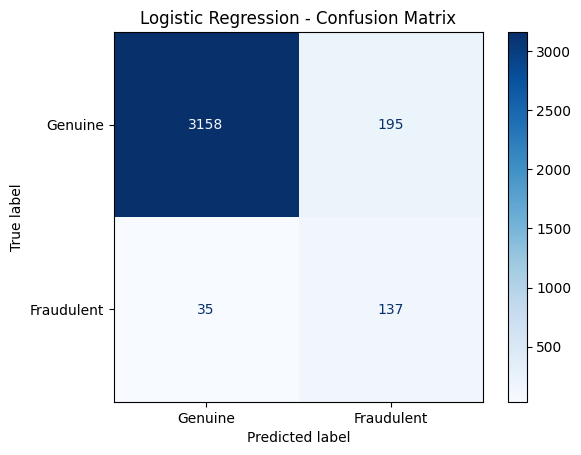

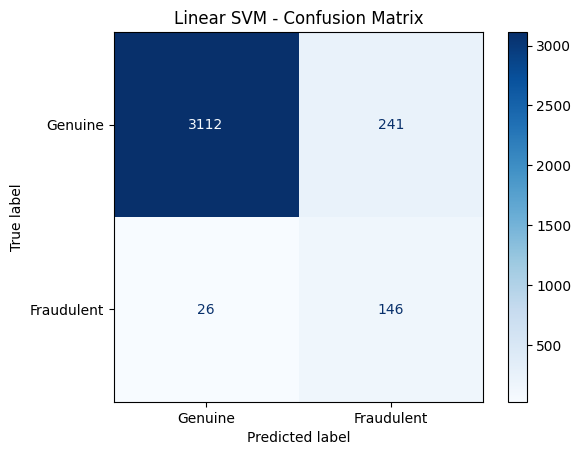

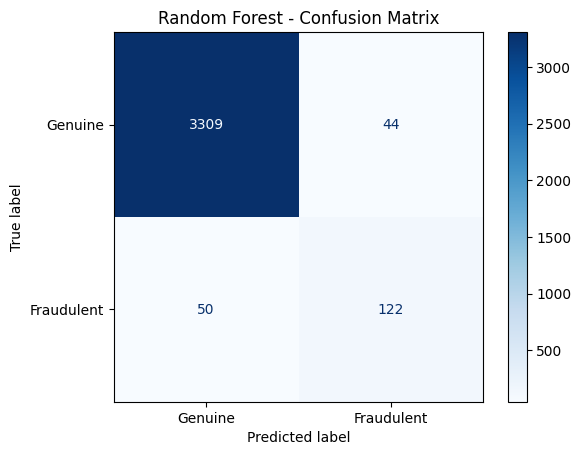

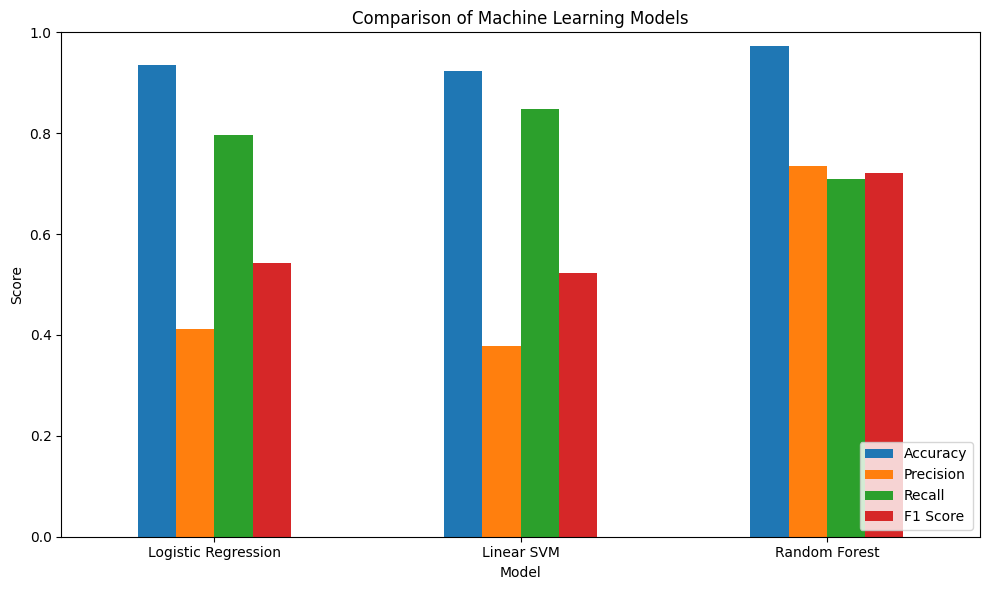

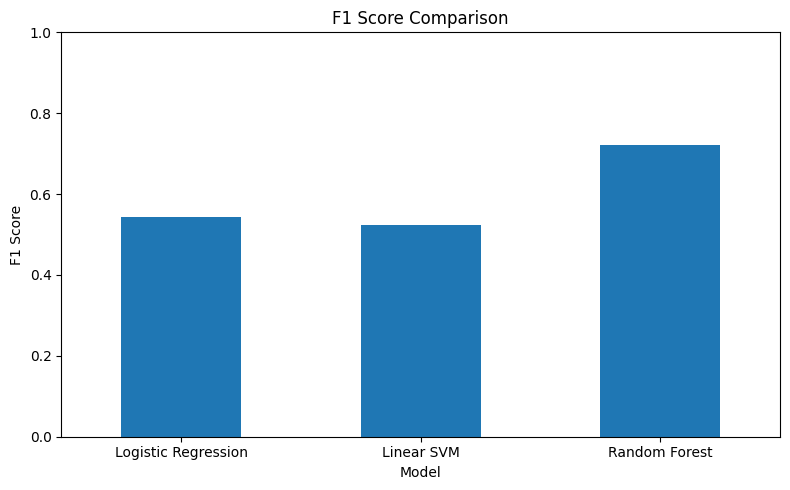

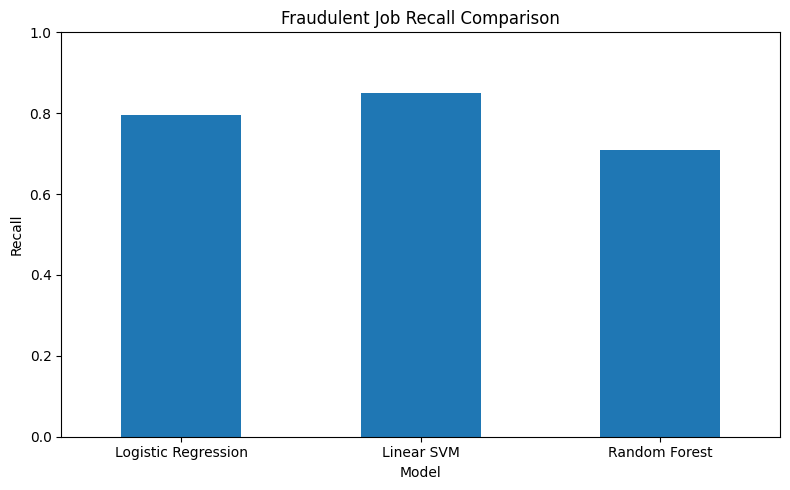

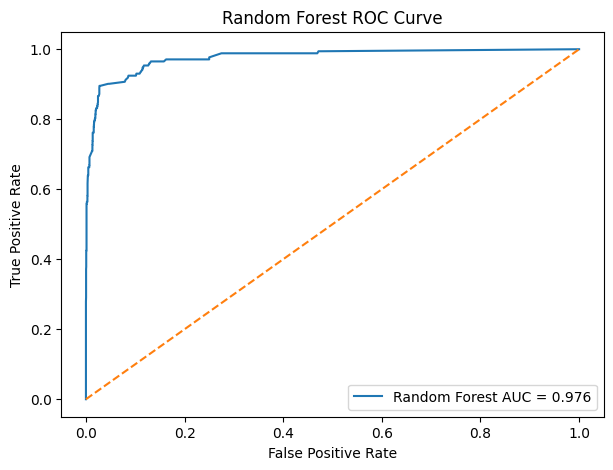

FINAL SELECTED MODEL: RANDOM FOREST

Accuracy : 0.9733333333333334
Precision: 0.7349397590361446
Recall   : 0.7093023255813954
F1 Score : 0.7218934911242604


In [68]:
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

# ============================================
# 1. CONFUSION MATRIX - LOGISTIC REGRESSION
# ============================================

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    display_labels=["Genuine", "Fraudulent"],
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()


# ============================================
# 2. CONFUSION MATRIX - LINEAR SVM
# ============================================

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm,
    display_labels=["Genuine", "Fraudulent"],
    cmap="Blues"
)

plt.title("Linear SVM - Confusion Matrix")
plt.show()


# ============================================
# 3. CONFUSION MATRIX - RANDOM FOREST
# ============================================

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=["Genuine", "Fraudulent"],
    cmap="Blues"
)

plt.title("Random Forest - Confusion Matrix")
plt.show()


# ============================================
# 4. MODEL COMPARISON BAR CHART
# ============================================

results_plot = results.set_index("Model")

results_plot[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparison of Machine Learning Models")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


# ============================================
# 5. F1 SCORE COMPARISON
# ============================================

results.plot(
    x="Model",
    y="F1 Score",
    kind="bar",
    legend=False,
    figsize=(8, 5)
)

plt.title("F1 Score Comparison")
plt.ylabel("F1 Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# ============================================
# 6. RECALL COMPARISON
# ============================================

results.plot(
    x="Model",
    y="Recall",
    kind="bar",
    legend=False,
    figsize=(8, 5)
)

plt.title("Fraudulent Job Recall Comparison")
plt.ylabel("Recall")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# ============================================
# 7. RANDOM FOREST ROC CURVE
# ============================================

# Probability that each job is fraudulent
rf_probabilities = rf_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    rf_probabilities
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest AUC = {roc_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()
plt.show()


# ============================================
# 8. PRINT FINAL RANDOM FOREST RESULTS
# ============================================

print("FINAL SELECTED MODEL: RANDOM FOREST")
print()

print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)